# 03 - Tuning our two strongest models and picking a winner
BCS 3101 Capstone: predicting telecom customer churn

In notebook 02 we compared four models. **Logistic Regression** and
**Random Forest** came out ahead (best ROC-AUC, and Logistic Regression had the best F1 too), so
those are the two we tune here.

"Tuning" means trying out different settings (called **hyperparameters**) for a model and keeping
whichever combination scores best - instead of just guessing one setting and hoping it's good.

This notebook:
1. Rebuilds the data and pipeline (same as notebooks 01 and 02).
2. Tunes Logistic Regression with `GridSearchCV`.
3. Tunes Random Forest with `GridSearchCV`.
4. Puts all four models - the two tuned ones plus the two we're leaving as-is - into one final
   comparison table, and picks a winner.

## Step 1: Get the data and pipeline

In [ ]:
import sys, warnings
sys.path.append('..')
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

from src.setup import prepare_everything, evaluate

X_train, X_test, y_train, y_test, preprocessing, cv = prepare_everything()

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

print('Pipeline ready. Ready to tune.')

Pipeline ready. Ready to tune.


## Step 2: What GridSearchCV actually does
`GridSearchCV` tries EVERY combination of settings you give it, scores each one with cross-validation
(the same 5-fold approach we've used throughout), and tells you which combination scored best.

The word "Grid" is literal - if you give it 3 options for one setting and 4 options for another,
it tries all 3 x 4 = 12 combinations, like checking every cell in a grid.

## Step 3: Tune Logistic Regression
The main setting we tune is **C**, the regularisation strength.

a smaller C tells the model "stay simple, don't chase every little pattern in the
training data too closely." A larger C tells it "fit the training data more closely." Too small and
the model is too simple to catch real patterns (underfitting); too large and it starts memorising
noise in the training data (overfitting). We let GridSearchCV try a spread of values and pick the
one that scores best on cross-validation, not on the training data itself.

In [2]:
from sklearn.linear_model import LogisticRegression

log_reg_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],   # smaller = simpler model, larger = fits training data closer
}

log_reg_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(max_iter=1000, random_state=42)),
])

log_reg_search = GridSearchCV(
    log_reg_pipeline,
    param_grid=log_reg_grid,
    cv=cv,
    scoring='f1',     # pick the setting that gives the best F1 score
    n_jobs=-1,         # use all available processor cores to run faster
)
log_reg_search.fit(X_train, y_train)

print('Best C found:', log_reg_search.best_params_['model__C'])
print('Best cross-validation F1 score:', round(log_reg_search.best_score_, 3))

Best C found: 100
Best cross-validation F1 score: 0.597


In [3]:
# look at every combination GridSearchCV tried, sorted best first
log_reg_results = pd.DataFrame(log_reg_search.cv_results_)
log_reg_results = log_reg_results[['param_model__C', 'mean_test_score', 'std_test_score']]
log_reg_results = log_reg_results.sort_values('mean_test_score', ascending=False)
log_reg_results.columns = ['C', 'F1 (mean)', 'F1 (spread)']
log_reg_results.round(3)

,C,F1 (mean),F1 (spread)
4,100.00,0.597,0.029
3,10.00,0.597,0.029
2,1.00,0.593,0.030
1,0.10,0.589,0.028
0,0.01,0.581,0.027


## Step 4: Tune Random Forest
We tune two settings together:

- **`n_estimators`**: how many trees are in the forest. More trees can help, up to a point, but also
  makes the model slower.
- **`max_depth`**: how deep each individual tree is allowed to grow. Shallower trees are simpler and
  less likely to overfit; deeper trees can capture more detail but risk memorising the training data.

In [4]:
from sklearn.ensemble import RandomForestClassifier

forest_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [4, 8, 12],
}

forest_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', RandomForestClassifier(random_state=42)),
])

forest_search = GridSearchCV(
    forest_pipeline,
    param_grid=forest_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
)
forest_search.fit(X_train, y_train)

print('Best settings found:', forest_search.best_params_)
print('Best cross-validation F1 score:', round(forest_search.best_score_, 3))

Best settings found: {'model__max_depth': 12, 'model__n_estimators': 100}
Best cross-validation F1 score: 0.575


In [5]:
forest_results = pd.DataFrame(forest_search.cv_results_)
forest_results = forest_results[[
    'param_model__n_estimators', 'param_model__max_depth', 'mean_test_score', 'std_test_score']]
forest_results = forest_results.sort_values('mean_test_score', ascending=False)
forest_results.columns = ['n_estimators', 'max_depth', 'F1 (mean)', 'F1 (spread)']
forest_results.round(3).head(9)

,n_estimators,max_depth,F1 (mean),F1 (spread)
6,100,12,0.575,0.016
5,300,8,0.572,0.015
7,200,12,0.572,0.016
8,300,12,0.571,0.019
4,200,8,0.571,0.020
3,100,8,0.569,0.017
0,100,4,0.489,0.014
2,300,4,0.486,0.018
1,200,4,0.485,0.019


## Step 5: Final comparison - all four models, side by side
Now we score the two TUNED models (using the best settings GridSearchCV found) alongside the two
we left with their default settings, all measured the exact same way (5-fold cross-validation,
accuracy / F1 / ROC-AUC), so the comparison is fair.

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# the two tuned models, using the best settings GridSearchCV found
tuned_log_reg = LogisticRegression(
    C=log_reg_search.best_params_['model__C'], max_iter=1000, random_state=42)

tuned_forest = RandomForestClassifier(
    n_estimators=forest_search.best_params_['model__n_estimators'],
    max_depth=forest_search.best_params_['model__max_depth'],
    random_state=42,
)

# the two we are leaving with their default settings from notebook 02
plain_tree = DecisionTreeClassifier(max_depth=6, random_state=42)
plain_knn = KNeighborsClassifier(n_neighbors=15)

final_comparison = pd.DataFrame([
    evaluate(tuned_log_reg, 'Logistic Regression (tuned)', X_train, y_train, preprocessing, cv),
    evaluate(tuned_forest, 'Random Forest (tuned)', X_train, y_train, preprocessing, cv),
    evaluate(plain_tree, 'Decision Tree (not tuned)', X_train, y_train, preprocessing, cv),
    evaluate(plain_knn, 'K-Nearest Neighbours (not tuned)', X_train, y_train, preprocessing, cv),
])
final_comparison = final_comparison.set_index('model').sort_values('f1 (mean)', ascending=False)
final_comparison

,accuracy (mean),accuracy (spread),f1 (mean),f1 (spread),roc_auc (mean),roc_auc (spread)
model,,,,,,
Logistic Regression (tuned),0.804,0.012,0.597,0.029,0.846,0.013
K-Nearest Neighbours (not tuned),0.787,0.008,0.585,0.014,0.824,0.009
Random Forest (tuned),0.798,0.009,0.575,0.016,0.833,0.009
Decision Tree (not tuned),0.789,0.012,0.564,0.030,0.824,0.016


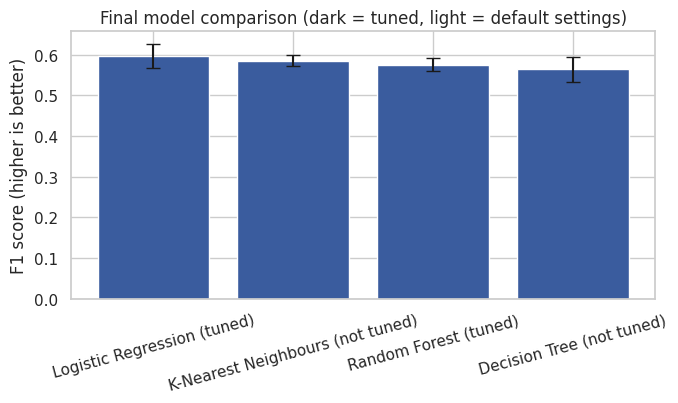

In [7]:
plt.figure(figsize=(7, 4.2))
plt.bar(
    final_comparison.index,
    final_comparison['f1 (mean)'],
    yerr=final_comparison['f1 (spread)'],
    capsize=5,
    color=['#3a5c9e' if 'tuned' in name else '#9fb3d1' for name in final_comparison.index],
)
plt.ylabel('F1 score (higher is better)')
plt.title('Final model comparison (dark = tuned, light = default settings)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../figures/final_model_comparison.png', dpi=150)
plt.show()

The four models were compared using the same 5-fold cross-validation procedure. The results show that Logistic Regression (tuned) had the highest F1 score (0.597) and ROC-AUC (0.846), while its accuracy was also the highest at 0.804. Random Forest (tuned) was close, with 0.798 accuracy, 0.575 F1, and 0.833 ROC-AUC. The two models that were not tuned performed slightly lower overall

This suggests that tuning improved the performance of the models, especially Logistic Regression. However, the improvement is not extremely large, so tuning provided a moderate rather than dramatic benefit. 

## Step 6: One honest check on the test set
Everything above used cross-validation on the TRAINING data only. The test set has not been touched
once since we split it in Step 1 - not to tune anything, not to pick a model. We now picked
a final model and check it once, honestly, on data it has never seen at all.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# The comparison table above shows Logistic Regression (tuned) winning on both F1 and ROC-AUC,
# so that's what we carry forward here. 

final_model = Pipeline([
    ('preprocessing', preprocessing),
    ('model', tuned_log_reg),
])
final_model.fit(X_train, y_train)   # train one last time, on ALL the training data

test_predictions = final_model.predict(X_test)
test_probabilities = final_model.predict_proba(X_test)[:, 1]

print('Test accuracy:', round(accuracy_score(y_test, test_predictions), 3))
print('Test F1:      ', round(f1_score(y_test, test_predictions), 3))
print('Test ROC-AUC: ', round(roc_auc_score(y_test, test_probabilities), 3))

Test accuracy: 0.801
Test F1:       0.593
Test ROC-AUC:  0.841


The final Logistic Regression model was trained using all of the available training data and then evaluated once on the completely unseen test set. The test results were 0.801 accuracy, 0.593 F1, and 0.841 ROC-AUC.
These scores are very close to the cross-validation results from Step 5, where Logistic Regression achieved 0.804 accuracy, 0.597 F1, and 0.846 ROC-AUC.

Because the test results are so close to the cross-validation results, there is no obvious sign that the model's performance changed substantially when applied to completely unseen data. If the test scores had been much lower than the cross-validation scores, it could indicate that the model was not generalizing well to unseen data, or that the cross-validation results had given an overly optimistic estimate of performance.